In [1]:
from sklearn.model_selection import train_test_split, KFold
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline  
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.preprocessing import MinMaxScaler, StandardScaler,RobustScaler,OneHotEncoder, OrdinalEncoder,label_binarize
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error,accuracy_score, classification_report, confusion_matrix,roc_curve, auc
from sklearn.ensemble import RandomForestClassifier

import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('bmh')


from joblib import dump

## 1.Loading dataset

In [2]:
df = pd.read_csv("Spotify_Song_Attributes.csv")
print( df.info(),df.describe())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10080 entries, 0 to 10079
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   trackName         10080 non-null  object 
 1   artistName        10080 non-null  object 
 2   msPlayed          10080 non-null  int64  
 3   genre             8580 non-null   object 
 4   danceability      9530 non-null   float64
 5   energy            9530 non-null   float64
 6   key               9530 non-null   float64
 7   loudness          9530 non-null   float64
 8   mode              9530 non-null   float64
 9   speechiness       9530 non-null   float64
 10  acousticness      9530 non-null   float64
 11  instrumentalness  9530 non-null   float64
 12  liveness          9530 non-null   float64
 13  valence           9530 non-null   float64
 14  tempo             9530 non-null   float64
 15  type              9530 non-null   object 
 16  id                9530 non-null   object

,trackName,artistName,msPlayed,genre,danceability,energy,key,loudness,mode,speechiness,...,liveness,valence,tempo,type,id,uri,track_href,analysis_url,duration_ms,time_signature
0,"""Honest""",Nico Collins,191772,NaN,0.476,0.799,4.0,-4.939,0.0,0.2120,...,0.2570,0.577,162.139,audio_features,7dTxqsaFGHOXwtzHINjfHv,spotify:track:7dTxqsaFGHOXwtzHINjfHv,https://api.spotify.com/v1/tracks/7dTxqsaFGHOX...,https://api.spotify.com/v1/audio-analysis/7dTx...,191948.0,4.0
1,"""In The Hall Of The Mountain King"" from Peer G...",London Symphony Orchestra,1806234,british orchestra,0.475,0.130,7.0,-17.719,1.0,0.0510,...,0.1010,0.122,112.241,audio_features,14Qcrx6Dfjvcj0H8oV8oUW,spotify:track:14Qcrx6Dfjvcj0H8oV8oUW,https://api.spotify.com/v1/tracks/14Qcrx6Dfjvc...,https://api.spotify.com/v1/audio-analysis/14Qc...,150827.0,4.0
2,#BrooklynBloodPop!,SyKo,145610,glitchcore,0.691,0.814,1.0,-3.788,0.0,0.1170,...,0.3660,0.509,132.012,audio_features,7K9Z3yFNNLv5kwTjQYGjnu,spotify:track:7K9Z3yFNNLv5kwTjQYGjnu,https://api.spotify.com/v1/tracks/7K9Z3yFNNLv5...,https://api.spotify.com/v1/audio-analysis/7K9Z...,145611.0,4.0
3,$10,Good Morning,25058,experimental pop,0.624,0.596,4.0,-9.804,1.0,0.0314,...,0.1190,0.896,120.969,audio_features,3koAwrM1RO0TGMeQJ3qt9J,spotify:track:3koAwrM1RO0TGMeQJ3qt9J,https://api.spotify.com/v1/tracks/3koAwrM1RO0T...,https://api.spotify.com/v1/audio-analysis/3koA...,89509.0,4.0
4,(I Just) Died In Your Arms,Cutting Crew,5504949,album rock,0.625,0.726,11.0,-11.402,0.0,0.0444,...,0.0625,0.507,124.945,audio_features,4ByEFOBuLXpCqvO1kw8Wdm,spotify:track:4ByEFOBuLXpCqvO1kw8Wdm,https://api.spotify.com/v1/tracks/4ByEFOBuLXpC...,https://api.spotify.com/v1/audio-analysis/4ByE...,280400.0,4.0


In [3]:
numeric = ['danceability', 'energy', 'key', 'loudness', 'mode', 
            'speechiness', 'acousticness', 'instrumentalness', 
            'liveness', 'valence', 'tempo','time_signature']

df[numeric].corr()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
danceability,1.000000,0.277729,0.020130,0.325836,-0.046042,0.180340,-0.261199,-0.229848,0.006503,0.484760,0.009501,0.220027
energy,0.277729,1.000000,0.018073,0.797092,-0.063628,0.159274,-0.765161,-0.367535,0.192994,0.448547,0.194298,0.159684
key,0.020130,0.018073,1.000000,0.004905,-0.130183,0.000495,-0.004327,-0.005269,0.035003,0.047748,0.012974,0.027260
loudness,0.325836,0.797092,0.004905,1.000000,-0.004765,0.117273,-0.644611,-0.574075,0.135925,0.382998,0.172717,0.152307
mode,-0.046042,-0.063628,-0.130183,-0.004765,1.000000,-0.060533,0.066310,-0.049038,-0.028997,0.013050,0.009756,-0.031605
speechiness,0.180340,0.159274,0.000495,0.117273,-0.060533,1.000000,-0.104853,-0.107087,0.138333,0.131875,0.110031,0.025669
acousticness,-0.261199,-0.765161,-0.004327,-0.644611,0.066310,-0.104853,1.000000,0.322443,-0.129970,-0.305580,-0.169778,-0.159009
instrumentalness,-0.229848,-0.367535,-0.005269,-0.574075,-0.049038,-0.107087,0.322443,1.000000,-0.055113,-0.308459,-0.097843,-0.076233
liveness,0.006503,0.192994,0.035003,0.135925,-0.028997,0.138333,-0.129970,-0.055113,1.000000,0.076991,0.013823,0.006476
valence,0.484760,0.448547,0.047748,0.382998,0.013050,0.131875,-0.305580,-0.308459,0.076991,1.000000,0.110969,0.136320


In [4]:
non_num = df.columns.drop(df[numeric])
non_num

Index(['trackName', 'artistName', 'msPlayed', 'genre', 'type', 'id', 'uri',
       'track_href', 'analysis_url', 'duration_ms'],
      dtype='object')

In [5]:
corr_matrix = df[numeric].corr()
for col in numeric:
    total_abs_corr = corr_matrix[col].abs().sum() - 1 
    print(f"{col}: {total_abs_corr:.2f}")

danceability: 2.06
energy: 3.44
key: 0.31
loudness: 3.31
mode: 0.50
speechiness: 1.14
acousticness: 2.93
instrumentalness: 2.19
liveness: 0.82
valence: 2.45
tempo: 0.92
time_signature: 1.02


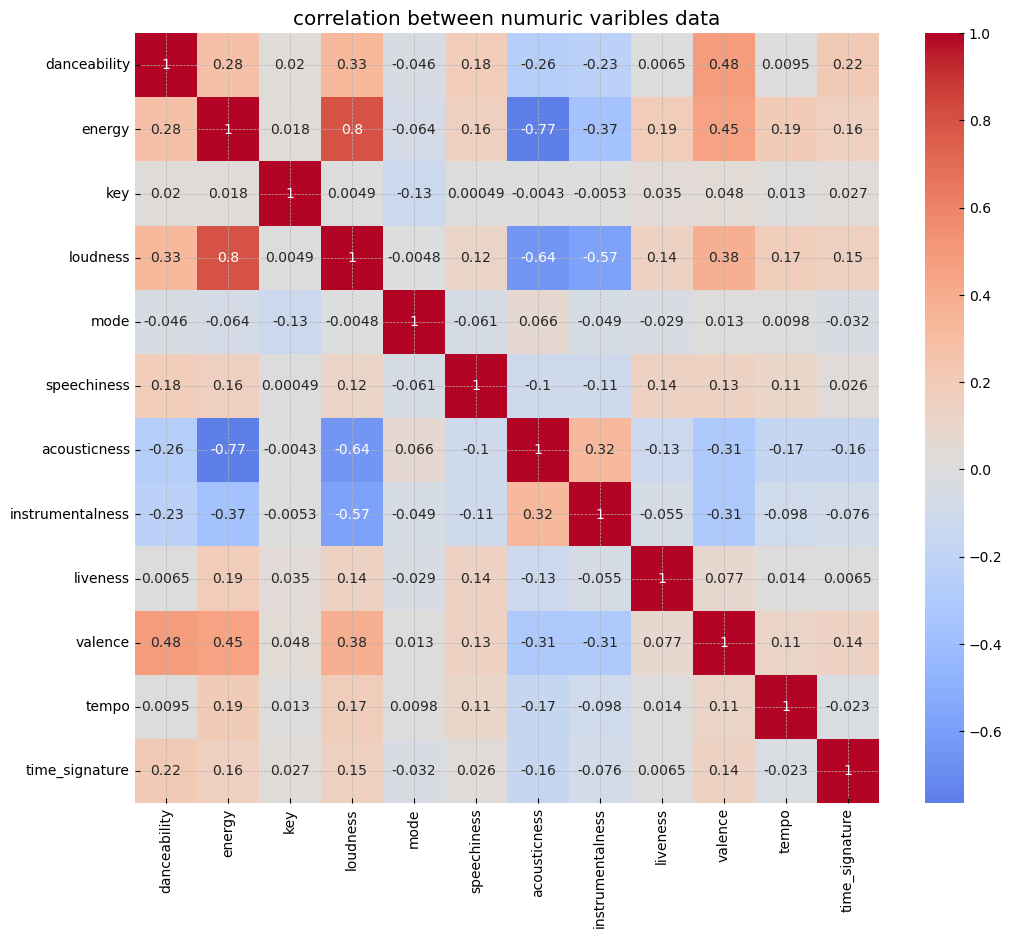

In [6]:
plt.figure(figsize=(12, 10))
sns.heatmap(df[numeric].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('correlation between numuric varibles data')
plt.show()

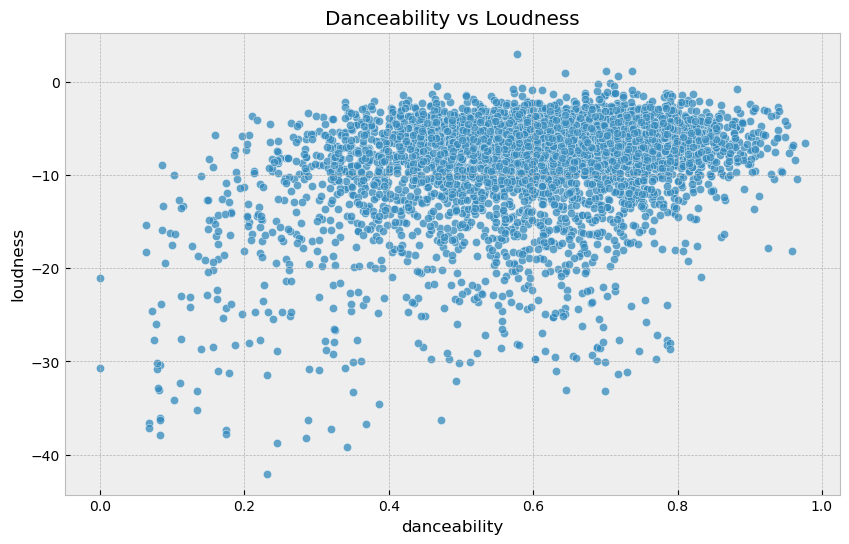

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(df, x='danceability', y='loudness', alpha=0.5)
plt.title('Danceability vs Loudness')
plt.show()

C:\Users\champ\AppData\Local\Temp\ipykernel_10360\3774321988.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[col].dropna() for col in df[numeric]],


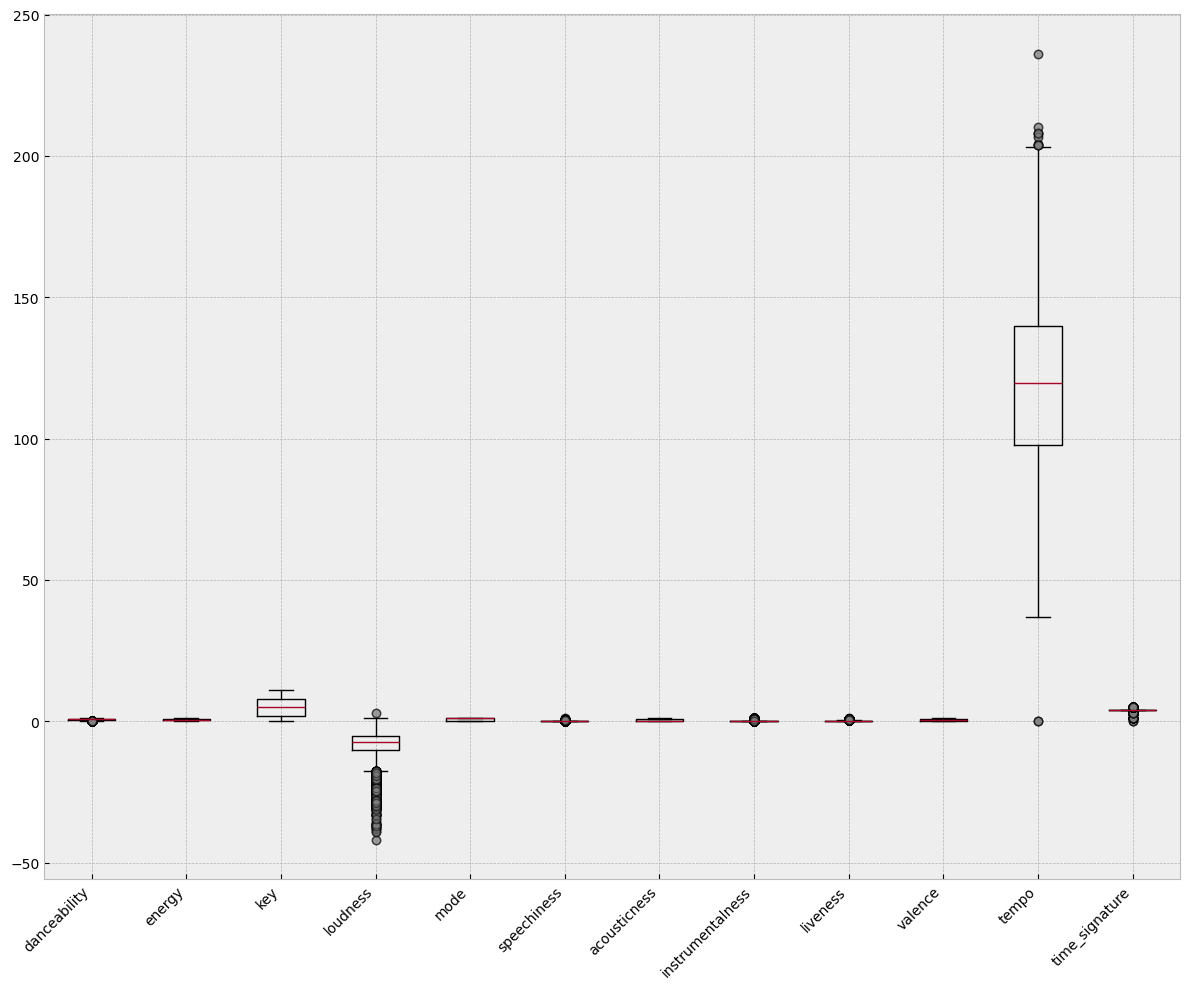

In [8]:
plt.figure(figsize=(12, 10))
plt.boxplot([df[col].dropna() for col in df[numeric]], 
            labels=numeric,
            flierprops={'marker': 'o', 'markerfacecolor': 'gray', 'alpha': 0.5})
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

## 2. Data Preprocessing & Cleaning Pipelines

In [9]:
df_nona = df[df['genre'].notna()].copy()
df_nona.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8580 entries, 1 to 10079
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   trackName         8580 non-null   object 
 1   artistName        8580 non-null   object 
 2   msPlayed          8580 non-null   int64  
 3   genre             8580 non-null   object 
 4   danceability      8580 non-null   float64
 5   energy            8580 non-null   float64
 6   key               8580 non-null   float64
 7   loudness          8580 non-null   float64
 8   mode              8580 non-null   float64
 9   speechiness       8580 non-null   float64
 10  acousticness      8580 non-null   float64
 11  instrumentalness  8580 non-null   float64
 12  liveness          8580 non-null   float64
 13  valence           8580 non-null   float64
 14  tempo             8580 non-null   float64
 15  type              8580 non-null   object 
 16  id                8580 non-null   object 
 17 

In [10]:
def remove_outliers_all_columns(df, columns, z_threshold=1.96):
    df_clean = df.copy()
    
    z_scores = pd.DataFrame()
    for col in columns:
        z_scores[col] = (df[col] - df[col].mean()) / df[col].std()

    mask = (z_scores.abs() <= z_threshold).all(axis=1)

    df_clean = df_clean[mask]
    
    return df_clean

In [11]:
df_clean = remove_outliers_all_columns(df_nona, numeric)

In [12]:
df_clean

,trackName,artistName,msPlayed,genre,danceability,energy,key,loudness,mode,speechiness,...,liveness,valence,tempo,type,id,uri,track_href,analysis_url,duration_ms,time_signature
2,#BrooklynBloodPop!,SyKo,145610,glitchcore,0.691,0.814,1.0,-3.788,0.0,0.1170,...,0.3660,0.509,132.012,audio_features,7K9Z3yFNNLv5kwTjQYGjnu,spotify:track:7K9Z3yFNNLv5kwTjQYGjnu,https://api.spotify.com/v1/tracks/7K9Z3yFNNLv5...,https://api.spotify.com/v1/audio-analysis/7K9Z...,145611.0,4.0
3,$10,Good Morning,25058,experimental pop,0.624,0.596,4.0,-9.804,1.0,0.0314,...,0.1190,0.896,120.969,audio_features,3koAwrM1RO0TGMeQJ3qt9J,spotify:track:3koAwrM1RO0TGMeQJ3qt9J,https://api.spotify.com/v1/tracks/3koAwrM1RO0T...,https://api.spotify.com/v1/audio-analysis/3koA...,89509.0,4.0
4,(I Just) Died In Your Arms,Cutting Crew,5504949,album rock,0.625,0.726,11.0,-11.402,0.0,0.0444,...,0.0625,0.507,124.945,audio_features,4ByEFOBuLXpCqvO1kw8Wdm,spotify:track:4ByEFOBuLXpCqvO1kw8Wdm,https://api.spotify.com/v1/tracks/4ByEFOBuLXpC...,https://api.spotify.com/v1/audio-analysis/4ByE...,280400.0,4.0
6,(lol),Eren Cannata,441335,guitar case,0.663,0.904,7.0,-4.710,1.0,0.0857,...,0.3410,0.675,118.024,audio_features,4DS2UXeR2V5W7R9aype6t1,spotify:track:4DS2UXeR2V5W7R9aype6t1,https://api.spotify.com/v1/tracks/4DS2UXeR2V5W...,https://api.spotify.com/v1/audio-analysis/4DS2...,217627.0,4.0
8,"...And to Those I Love, Thanks for Sticking Ar...",$uicideboy$,120005,cloud rap,0.792,0.511,2.0,-6.876,1.0,0.0409,...,0.1400,0.111,113.983,audio_features,30QR0ndUdiiMQMA9g1PGCm,spotify:track:30QR0ndUdiiMQMA9g1PGCm,https://api.spotify.com/v1/tracks/30QR0ndUdiiM...,https://api.spotify.com/v1/audio-analysis/30QR...,168490.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10069,Young And Beautiful,Lana Del Rey,12267791,art pop,0.324,0.416,11.0,-8.920,0.0,0.0368,...,0.1100,0.151,113.986,audio_features,2nMeu6UenVvwUktBCpLMK9,spotify:track:2nMeu6UenVvwUktBCpLMK9,https://api.spotify.com/v1/tracks/2nMeu6UenVvw...,https://api.spotify.com/v1/audio-analysis/2nMe...,236053.0,4.0
10070,Young Dumb & Broke,Khalid,484456,pop,0.799,0.539,1.0,-6.351,1.0,0.0421,...,0.1650,0.394,136.948,audio_features,5Z3GHaZ6ec9bsiI5BenrbY,spotify:track:5Z3GHaZ6ec9bsiI5BenrbY,https://api.spotify.com/v1/tracks/5Z3GHaZ6ec9b...,https://api.spotify.com/v1/audio-analysis/5Z3G...,202547.0,4.0
10073,Younger,Jonas Blue,2560215,pop,0.784,0.845,3.0,-2.793,1.0,0.0596,...,0.0740,0.888,105.981,audio_features,4D7ERaKgv8NAeck8RzUtRz,spotify:track:4D7ERaKgv8NAeck8RzUtRz,https://api.spotify.com/v1/tracks/4D7ERaKgv8NA...,https://api.spotify.com/v1/audio-analysis/4D7E...,194721.0,4.0
10074,Younger,Ruel,5272303,alt z,0.745,0.477,11.0,-7.706,0.0,0.0880,...,0.1200,0.454,136.055,audio_features,2qXicQG06oT0ijKBznpgQv,spotify:track:2qXicQG06oT0ijKBznpgQv,https://api.spotify.com/v1/tracks/2qXicQG06oT0...,https://api.spotify.com/v1/audio-analysis/2qXi...,222320.0,4.0


In [13]:
cat= ['genre']

In [14]:
num_pipeline = Pipeline([
    ('std_scaler', MinMaxScaler())
])

In [15]:
preprocessing = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, numeric),
        ('cat', OneHotEncoder(sparse_output=False, 
                            handle_unknown='ignore'), 
        cat)
    ])
preprocessing

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('std_scaler',
                                                  MinMaxScaler())]),
                                 ['danceability', 'energy', 'key', 'loudness',
                                  'mode', 'speechiness', 'acousticness',
                                  'instrumentalness', 'liveness', 'valence',
                                  'tempo', 'time_signature']),
                                ('cat',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['genre'])])

C:\Users\champ\AppData\Local\Temp\ipykernel_10360\3025060969.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df_clean[col].dropna() for col in df_clean[numeric]],


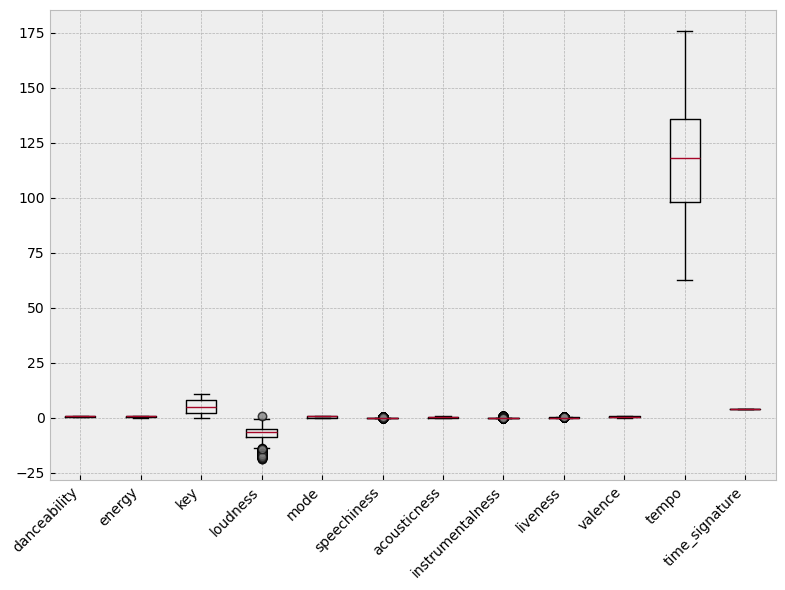

In [16]:
plt.figure(figsize=(8, 6))
plt.boxplot([df_clean[col].dropna() for col in df_clean[numeric]], 
            labels=numeric,
            flierprops={'marker': 'o', 'markerfacecolor': 'gray', 'alpha': 0.5})
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

In [17]:
numeric.remove('time_signature')

In [18]:
len(df_clean['genre'].value_counts())

413

In [19]:
train_set, test_set = train_test_split( df_clean, test_size=0.2,  shuffle=True,  random_state=2025)
train_prepared = preprocessing.fit_transform(train_set)
test_prepared = preprocessing.transform(test_set)
train_prepared.shape,test_prepared.shape

((4464, 415), (1116, 415))

## 3. Training machine learning model

In [20]:
df_reg= df_clean[['loudness','acousticness', 'tempo','energy']]
df_reg

,loudness,acousticness,tempo,energy
2,-3.788,0.016400,132.012,0.814
3,-9.804,0.475000,120.969,0.596
4,-11.402,0.015800,124.945,0.726
6,-4.710,0.000708,118.024,0.904
8,-6.876,0.124000,113.983,0.511
...,...,...,...,...
10069,-8.920,0.262000,113.986,0.416
10070,-6.351,0.199000,136.948,0.539
10073,-2.793,0.286000,105.981,0.845
10074,-7.706,0.202000,136.055,0.477


In [21]:
df_reg_train, df_reg_test = train_test_split(df_reg,
                                             train_size=0.8,
                                             random_state=2025,
                                             shuffle=True)
df_reg_test.shape,df_reg_train.shape

((1116, 4), (4464, 4))

In [22]:
df_reg_x_test = df_reg_test.drop(labels='energy', axis=1)
df_reg_x_train = df_reg_train.drop(labels='energy', axis=1)
df_reg_y_test = df_reg_test['energy'].copy()
df_reg_y_train = df_reg_train['energy'].copy()


### linear regression

In [23]:
Model_0 = Pipeline([('LIN_reg',LinearRegression())])
Model_0.get_params()

param_grid_0 = {
    'verbose': [True, False]
}
grid_search_0 = GridSearchCV(Model_0,
                          param_grid=param_grid_0,
                          cv=KFold(5, shuffle=True, random_state=0),
                          scoring='neg_mean_squared_error',
                          refit=True)
grid_search_0.fit(df_reg_x_train, df_reg_y_train)
grid_search_0.best_params_
FModel_0 = grid_search_0.best_estimator_

[Pipeline] ........... (step 1 of 1) Processing LIN_reg, total=   0.0s
[Pipeline] ........... (step 1 of 1) Processing LIN_reg, total=   0.0s
[Pipeline] ........... (step 1 of 1) Processing LIN_reg, total=   0.0s
[Pipeline] ........... (step 1 of 1) Processing LIN_reg, total=   0.0s
[Pipeline] ........... (step 1 of 1) Processing LIN_reg, total=   0.0s
[Pipeline] ........... (step 1 of 1) Processing LIN_reg, total=   0.0s


In [24]:
FModel_0

Pipeline(steps=[('LIN_reg', LinearRegression())], verbose=True)

In [25]:
dump(FModel_0, 'model_linear_reg.joblib')

['model_linear_reg.joblib']

### Ridge

In [26]:
Model_1 = Pipeline([('ridge_reg',Ridge())])
Model_1.get_params()
param_grid_1 = {
    'verbose': [True, False],
    'ridge_reg__alpha': [0, 0.001, 0.01, 0.1, 0.2, 0.5, 1]
}
grid_search_1 = GridSearchCV(Model_1,
                          param_grid=param_grid_1,
                          cv=KFold(5, shuffle=True, random_state=0),
                          scoring='neg_mean_squared_error',
                          refit=True)
grid_search_1
grid_search_1.fit(df_reg_x_train, df_reg_y_train)
grid_search_1.best_params_
FModel_1 = grid_search_1.best_estimator_

[Pipeline] ......... (step 1 of 1) Processing ridge_reg, total=   0.0s
[Pipeline] ......... (step 1 of 1) Processing ridge_reg, total=   0.0s
[Pipeline] ......... (step 1 of 1) Processing ridge_reg, total=   0.0s
[Pipeline] ......... (step 1 of 1) Processing ridge_reg, total=   0.0s
[Pipeline] ......... (step 1 of 1) Processing ridge_reg, total=   0.0s
[Pipeline] ......... (step 1 of 1) Processing ridge_reg, total=   0.0s
[Pipeline] ......... (step 1 of 1) Processing ridge_reg, total=   0.0s
[Pipeline] ......... (step 1 of 1) Processing ridge_reg, total=   0.0s
[Pipeline] ......... (step 1 of 1) Processing ridge_reg, total=   0.0s
[Pipeline] ......... (step 1 of 1) Processing ridge_reg, total=   0.0s
[Pipeline] ......... (step 1 of 1) Processing ridge_reg, total=   0.0s
[Pipeline] ......... (step 1 of 1) Processing ridge_reg, total=   0.0s
[Pipeline] ......... (step 1 of 1) Processing ridge_reg, total=   0.0s
[Pipeline] ......... (step 1 of 1) Processing ridge_reg, total=   0.0s
[Pipel

In [27]:
FModel_1

Pipeline(steps=[('ridge_reg', Ridge(alpha=0.01))], verbose=True)

In [28]:
dump(FModel_1, 'model_Ridge.joblib')

['model_Ridge.joblib']

### Lasso

In [29]:
Model_2 = Pipeline([('lasso_reg',Lasso())])
Model_2.get_params()
param_grid_2 = {
    'verbose': [True, False],
    'lasso_reg__alpha': [0, 0.001, 0.01, 0.1, 0.2, 0.5, 1]
}
grid_search_2 = GridSearchCV(Model_2,
                          param_grid=param_grid_2,
                          cv=KFold(5, shuffle=True, random_state=0),
                          scoring='neg_mean_squared_error',
                          refit=True)
grid_search_2.fit(df_reg_x_train, df_reg_y_train)
grid_search_2.best_params_
FModel_2 = grid_search_2.best_estimator_

c:\Users\champ\miniconda3\envs\aml\lib\site-packages\sklearn\base.py:1473: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
c:\Users\champ\miniconda3\envs\aml\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
c:\Users\champ\miniconda3\envs\aml\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.299e+01, tolerance: 1.395e-02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  

[Pipeline] ......... (step 1 of 1) Processing lasso_reg, total=   0.0s
[Pipeline] ......... (step 1 of 1) Processing lasso_reg, total=   0.0s
[Pipeline] ......... (step 1 of 1) Processing lasso_reg, total=   0.0s
[Pipeline] ......... (step 1 of 1) Processing lasso_reg, total=   0.0s
[Pipeline] ......... (step 1 of 1) Processing lasso_reg, total=   0.0s


c:\Users\champ\miniconda3\envs\aml\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.268e+01, tolerance: 1.390e-02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
c:\Users\champ\miniconda3\envs\aml\lib\site-packages\sklearn\base.py:1473: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
c:\Users\champ\miniconda3\envs\aml\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  

[Pipeline] ......... (step 1 of 1) Processing lasso_reg, total=   0.0s
[Pipeline] ......... (step 1 of 1) Processing lasso_reg, total=   0.0s
[Pipeline] ......... (step 1 of 1) Processing lasso_reg, total=   0.0s
[Pipeline] ......... (step 1 of 1) Processing lasso_reg, total=   0.0s
[Pipeline] ......... (step 1 of 1) Processing lasso_reg, total=   0.0s
[Pipeline] ......... (step 1 of 1) Processing lasso_reg, total=   0.0s
[Pipeline] ......... (step 1 of 1) Processing lasso_reg, total=   0.0s
[Pipeline] ......... (step 1 of 1) Processing lasso_reg, total=   0.0s
[Pipeline] ......... (step 1 of 1) Processing lasso_reg, total=   0.0s
[Pipeline] ......... (step 1 of 1) Processing lasso_reg, total=   0.0s
[Pipeline] ......... (step 1 of 1) Processing lasso_reg, total=   0.0s
[Pipeline] ......... (step 1 of 1) Processing lasso_reg, total=   0.0s
[Pipeline] ......... (step 1 of 1) Processing lasso_reg, total=   0.0s
[Pipeline] ......... (step 1 of 1) Processing lasso_reg, total=   0.0s
[Pipel

c:\Users\champ\miniconda3\envs\aml\lib\site-packages\sklearn\base.py:1473: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
c:\Users\champ\miniconda3\envs\aml\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
c:\Users\champ\miniconda3\envs\aml\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.877e+01, tolerance: 1.749e-02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  

In [30]:
FModel_2

Pipeline(steps=[('lasso_reg', Lasso(alpha=0))], verbose=True)

In [31]:
dump(FModel_2, 'model_Lasso.joblib')

['model_Lasso.joblib']

### DecisionTreeRegressor

In [32]:
Model_3 = Pipeline([('dtree_reg',DecisionTreeRegressor())])
Model_3.get_params()
param_grid_3 = {
    'dtree_reg__max_depth': [3, 6, 9, None],        
    'dtree_reg__min_samples_split': [2, 5, 10]      
}
grid_search_3 = GridSearchCV(Model_3,
                          param_grid=param_grid_3,
                          cv=KFold(5, shuffle=True, random_state=0),
                          scoring='neg_mean_squared_error',
                          refit=True)
grid_search_3.fit(df_reg_x_train, df_reg_y_train)
grid_search_3.best_params_
FModel_3 = grid_search_3.best_estimator_

In [33]:
FModel_3

Pipeline(steps=[('dtree_reg', DecisionTreeRegressor())])

In [34]:
dump(FModel_3, 'model_DecisionTreeRegressor.joblib')

['model_DecisionTreeRegressor.joblib']

### Classification Task 

In [35]:
danceability_cat = pd.cut(df_clean['danceability'],
                         bins=[-1, 0.3, 0.6,11], 
                        labels=['low', 'medium', 'high'])

In [36]:
df_class= df_clean[['loudness','energy','tempo','danceability']]
df_class.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5580 entries, 2 to 10078
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   loudness      5580 non-null   float64
 1   energy        5580 non-null   float64
 2   tempo         5580 non-null   float64
 3   danceability  5580 non-null   float64
dtypes: float64(4)
memory usage: 218.0 KB


In [37]:
danceability_cat.info()

<class 'pandas.core.series.Series'>
Index: 5580 entries, 2 to 10078
Series name: danceability
Non-Null Count  Dtype   
--------------  -----   
5580 non-null   category
dtypes: category(1)
memory usage: 49.2 KB


In [38]:
train_set, test_set, danceability_cat_train, danceability_cat_test = train_test_split(
    df_class,  
    danceability_cat,
    test_size=0.2, 
    shuffle=True,  
    random_state=2025,  
    stratify=danceability_cat  )

In [39]:
df_class_y_train = danceability_cat_train
df_class_x_train = train_set.drop(labels='danceability', axis=1)
df_class_y_test = danceability_cat_test 
df_class_x_test = test_set.drop(labels='danceability', axis=1)

###  Logistic Regression  

In [40]:
Model_4 = Pipeline([('Log_reg',LogisticRegression())])
Model_4.get_params()
param_grid_4 = {
    'Log_reg__penalty': ['l2', None],  
    'Log_reg__C': [0.1, 1.0, 10.0]    }
grid_search_4 = GridSearchCV(Model_4,
                          param_grid=param_grid_4,
                          cv=KFold(5, shuffle=True, random_state=0),
                          scoring='neg_mean_squared_error',
                          refit=True)
grid_search_4.fit(df_class_x_train, df_class_y_train)
grid_search_4.best_params_

FModel_4 = grid_search_4.best_estimator_

c:\Users\champ\miniconda3\envs\aml\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\champ\miniconda3\envs\aml\lib\site-packages\sklearn\model_selection\_validation.py:982: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\champ\miniconda3\envs\aml\lib\site-packages\sklearn\model_selection\_validation.py", line 971, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\Users\champ\miniconda3\envs\a

In [41]:
dump(FModel_4, 'model_LogisticRegression.joblib')

['model_LogisticRegression.joblib']

#### Random Forest Classifier

In [42]:
Model_5 = Pipeline([('RanFclass',RandomForestClassifier())])
Model_5.get_params()
param_grid_5 = {
    'RanFclass__n_estimators': [50, 100, 200],

    'RanFclass__max_depth': [3, 5, 7, None]
}
grid_search_5 = GridSearchCV(Model_5,
                          param_grid=param_grid_5,
                          cv=KFold(5, shuffle=True, random_state=0),
                          scoring='neg_mean_squared_error',
                          refit=True)
grid_search_5.fit(df_class_x_train, df_class_y_train)
grid_search_5.best_params_
FModel_5 = grid_search_5.best_estimator_

c:\Users\champ\miniconda3\envs\aml\lib\site-packages\sklearn\model_selection\_validation.py:982: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\champ\miniconda3\envs\aml\lib\site-packages\sklearn\model_selection\_validation.py", line 971, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\Users\champ\miniconda3\envs\aml\lib\site-packages\sklearn\metrics\_scorer.py", line 279, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
  File "c:\Users\champ\miniconda3\envs\aml\lib\site-packages\sklearn\metrics\_scorer.py", line 376, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
  File "c:\Users\champ\miniconda3\envs\aml\lib\site-packages\sklearn\utils\_param_validation.py", line 213, in wrapper
    return func(*args, **kwargs)
  File "c:\Users\champ\minicon

In [43]:
dump(FModel_5, 'RandomForestClassifier.joblib')

['RandomForestClassifier.joblib']

## 4. Dataset merge

In [44]:
df_clean

,trackName,artistName,msPlayed,genre,danceability,energy,key,loudness,mode,speechiness,...,liveness,valence,tempo,type,id,uri,track_href,analysis_url,duration_ms,time_signature
2,#BrooklynBloodPop!,SyKo,145610,glitchcore,0.691,0.814,1.0,-3.788,0.0,0.1170,...,0.3660,0.509,132.012,audio_features,7K9Z3yFNNLv5kwTjQYGjnu,spotify:track:7K9Z3yFNNLv5kwTjQYGjnu,https://api.spotify.com/v1/tracks/7K9Z3yFNNLv5...,https://api.spotify.com/v1/audio-analysis/7K9Z...,145611.0,4.0
3,$10,Good Morning,25058,experimental pop,0.624,0.596,4.0,-9.804,1.0,0.0314,...,0.1190,0.896,120.969,audio_features,3koAwrM1RO0TGMeQJ3qt9J,spotify:track:3koAwrM1RO0TGMeQJ3qt9J,https://api.spotify.com/v1/tracks/3koAwrM1RO0T...,https://api.spotify.com/v1/audio-analysis/3koA...,89509.0,4.0
4,(I Just) Died In Your Arms,Cutting Crew,5504949,album rock,0.625,0.726,11.0,-11.402,0.0,0.0444,...,0.0625,0.507,124.945,audio_features,4ByEFOBuLXpCqvO1kw8Wdm,spotify:track:4ByEFOBuLXpCqvO1kw8Wdm,https://api.spotify.com/v1/tracks/4ByEFOBuLXpC...,https://api.spotify.com/v1/audio-analysis/4ByE...,280400.0,4.0
6,(lol),Eren Cannata,441335,guitar case,0.663,0.904,7.0,-4.710,1.0,0.0857,...,0.3410,0.675,118.024,audio_features,4DS2UXeR2V5W7R9aype6t1,spotify:track:4DS2UXeR2V5W7R9aype6t1,https://api.spotify.com/v1/tracks/4DS2UXeR2V5W...,https://api.spotify.com/v1/audio-analysis/4DS2...,217627.0,4.0
8,"...And to Those I Love, Thanks for Sticking Ar...",$uicideboy$,120005,cloud rap,0.792,0.511,2.0,-6.876,1.0,0.0409,...,0.1400,0.111,113.983,audio_features,30QR0ndUdiiMQMA9g1PGCm,spotify:track:30QR0ndUdiiMQMA9g1PGCm,https://api.spotify.com/v1/tracks/30QR0ndUdiiM...,https://api.spotify.com/v1/audio-analysis/30QR...,168490.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10069,Young And Beautiful,Lana Del Rey,12267791,art pop,0.324,0.416,11.0,-8.920,0.0,0.0368,...,0.1100,0.151,113.986,audio_features,2nMeu6UenVvwUktBCpLMK9,spotify:track:2nMeu6UenVvwUktBCpLMK9,https://api.spotify.com/v1/tracks/2nMeu6UenVvw...,https://api.spotify.com/v1/audio-analysis/2nMe...,236053.0,4.0
10070,Young Dumb & Broke,Khalid,484456,pop,0.799,0.539,1.0,-6.351,1.0,0.0421,...,0.1650,0.394,136.948,audio_features,5Z3GHaZ6ec9bsiI5BenrbY,spotify:track:5Z3GHaZ6ec9bsiI5BenrbY,https://api.spotify.com/v1/tracks/5Z3GHaZ6ec9b...,https://api.spotify.com/v1/audio-analysis/5Z3G...,202547.0,4.0
10073,Younger,Jonas Blue,2560215,pop,0.784,0.845,3.0,-2.793,1.0,0.0596,...,0.0740,0.888,105.981,audio_features,4D7ERaKgv8NAeck8RzUtRz,spotify:track:4D7ERaKgv8NAeck8RzUtRz,https://api.spotify.com/v1/tracks/4D7ERaKgv8NA...,https://api.spotify.com/v1/audio-analysis/4D7E...,194721.0,4.0
10074,Younger,Ruel,5272303,alt z,0.745,0.477,11.0,-7.706,0.0,0.0880,...,0.1200,0.454,136.055,audio_features,2qXicQG06oT0ijKBznpgQv,spotify:track:2qXicQG06oT0ijKBznpgQv,https://api.spotify.com/v1/tracks/2qXicQG06oT0...,https://api.spotify.com/v1/audio-analysis/2qXi...,222320.0,4.0


In [45]:
df_model = df_clean[['loudness','acousticness', 'tempo','energy','danceability']]


In [46]:
df_model.to_csv('df_model.csv')